In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import matplotlib.pyplot as plt

In [3]:
# creating the dataset

data = {
    "Weight": [79,69,73,95,82,55,69,71,64,69],
    "Height": [1.80,1.68,1.82,1.70,1.87,1.55,1.50,1.78,1.67,1.64],
    "Age": [35,39,25,60,27,18,89,42,16,52],
    "Gender": ["Male","Male","Male","Male","Male",
               "Female","Female","Female","Female","Female"]
}

df = pd.DataFrame(data)
print(df)

   Weight  Height  Age  Gender
0      79    1.80   35    Male
1      69    1.68   39    Male
2      73    1.82   25    Male
3      95    1.70   60    Male
4      82    1.87   27    Male
5      55    1.55   18  Female
6      69    1.50   89  Female
7      71    1.78   42  Female
8      64    1.67   16  Female
9      69    1.64   52  Female


In [4]:
# Encoding gender
encoder = LabelEncoder()
df["Gender"] = encoder.fit_transform(df["Gender"])
print(df)

   Weight  Height  Age  Gender
0      79    1.80   35       1
1      69    1.68   39       1
2      73    1.82   25       1
3      95    1.70   60       1
4      82    1.87   27       1
5      55    1.55   18       0
6      69    1.50   89       0
7      71    1.78   42       0
8      64    1.67   16       0
9      69    1.64   52       0


In [5]:
# selecting features and Targets

X = df[["Height","Age","Gender"]]
y = df["Weight"]

In [7]:
# splitting dataset
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [8]:
# Training the model
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [9]:
# Making predictions
y_pred = model.predict(X_test)
print("Predicted Weights: ")
print(y_pred)

Predicted Weights: 
[56.85651025 79.10576115]


In [10]:
#Evaluating the model

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE : 8.624625451606978
RMSE: 8.750881506936468
R2 Score: -11.252468343750825


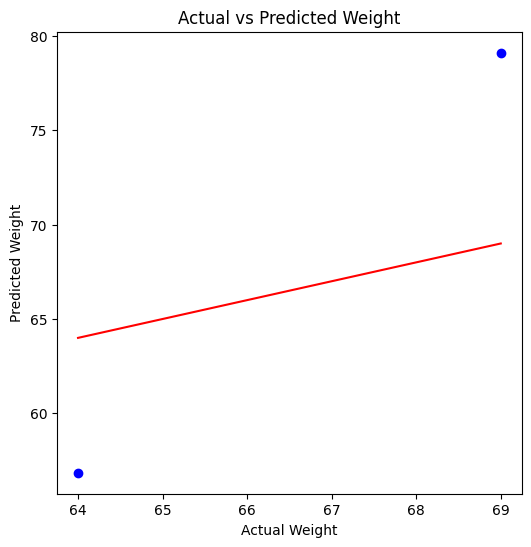

In [11]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred, color="blue")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.xlabel("Actual Weight")
plt.ylabel("Predicted Weight")
plt.title("Actual vs Predicted Weight")

plt.show()